# FinBERT Fine-Tuning for Financial Sentiment Analysis

In [75]:
import torch
import numpy as np
import pandas as pd

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Zero-Shot Evaluation

In [76]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [78]:
train_df = pd.read_csv('../data/processed/train.csv')
valid_df = pd.read_csv('../data/processed/valid.csv')
test_df = pd.read_csv('../data/processed/test.csv')

In [79]:
X_test_raw = test_df['sentence']
X_test = test_df['clean_text']
y_test = test_df['sentiment']

In [80]:
from transformers import pipeline

finbert = pipeline(
    "sentiment-analysis",
    model = "ProsusAI/finbert",
    tokenizer = "ProsusAI/finbert"

)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [81]:
zero_shot_results = finbert(list(X_test_raw), batch_size=32)
y_pred = [r['label'].lower() for r in zero_shot_results]

In [82]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.80      0.97      0.88       181
     neutral       0.96      0.87      0.91       862
    positive       0.82      0.91      0.86       409

    accuracy                           0.89      1452
   macro avg       0.86      0.92      0.88      1452
weighted avg       0.90      0.89      0.89      1452



## 2. Fine-Tuning

### 2.1 Data Preparation

In [83]:
X_train = train_df['sentence']
y_train = train_df['sentiment']

X_val = valid_df['sentence']
y_val = valid_df['sentiment']

X_test = test_df['sentence']
y_test = test_df['sentiment']

In [84]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

In [85]:
class CustomDataset:

    def __init__(self, text, labels, tokenizer, max_len = 128):
        self.text = text    
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.text)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.text[idx],
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
            ) 
        return {
            'input_ids' : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [86]:
train_dataset = CustomDataset(
    text = train_df['sentence'].tolist(),
    labels=y_train,
    tokenizer=tokenizer)

valid_dataset = CustomDataset(
    text=valid_df['sentence'].tolist(),
    labels=y_val,
    tokenizer=tokenizer)

In [87]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [88]:
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
for name, param in model.named_parameters():
    if not any(f"encoder.layer.{i}" in name for i in [10, 11]) and "classifier" not in name:
        param.requires_grad = False
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### 2.2 Model Setup (Layer Freezing)

In [89]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr = 1e-5, weight_decay=0.01)

### 2.3 Optimizer & Scheduler

In [90]:
from transformers import get_linear_schedule_with_warmup

num_epochs = 5
training_steps = len(train_loader) * num_epochs
warmup_steps = int(training_steps * 0.1)

scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_training_steps=training_steps,
    num_warmup_steps=warmup_steps
)

In [91]:
from torch.nn import utils

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        label = batch['label'].to(device)
        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            labels=label,
            attention_mask=attention_mask
        )

        outputs.loss.backward()
        utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += outputs.loss.item()

    return total_loss / len(loader)

### 2.4 Training & Evaluation Functions

In [92]:
from torch import argmax

def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            label = batch['label'].to(device)

            outputs = model(
                input_ids = input_ids,
                labels = label,
                attention_mask = attention_mask
            )

            total_loss += outputs.loss.item()
            all_preds.extend(argmax(outputs.logits, dim=1).cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    return total_loss/len(loader), all_preds, all_labels

In [93]:
from sklearn.metrics import f1_score

def epoch_loop():
    best_f1 = 0
    no_improve = 0
    patience = 2

    for epoch in range(num_epochs):
        train_loss = train_epoch(model=model.to(device),
                                 loader = train_loader,
                                 optimizer = optimizer,
                                 device = device,
                                 scheduler=scheduler)

        valid_loss, val_preds, val_labels = eval_epoch(model=model,
                                                       loader=valid_loader,
                                                       device=device)
        current_f1 = f1_score(val_labels, val_preds, average="weighted")

        if current_f1 > best_f1:
            best_f1 = current_f1
            no_improve = 0
            torch.save(model.state_dict(), "../models/finetuned_finbert_tweaked1")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {valid_loss:.4f} | Val F1: {current_f1:.4f}")

### 2.5 Training

In [94]:
#epoch_loop()

## 3. Evaluation on Test Set

Test Loss: 0.2795 | Test F1: 0.8990
              precision    recall  f1-score   support

    negative       0.86      0.91      0.89       181
     neutral       0.93      0.91      0.92       862
    positive       0.85      0.87      0.86       409

    accuracy                           0.90      1452
   macro avg       0.88      0.90      0.89      1452
weighted avg       0.90      0.90      0.90      1452



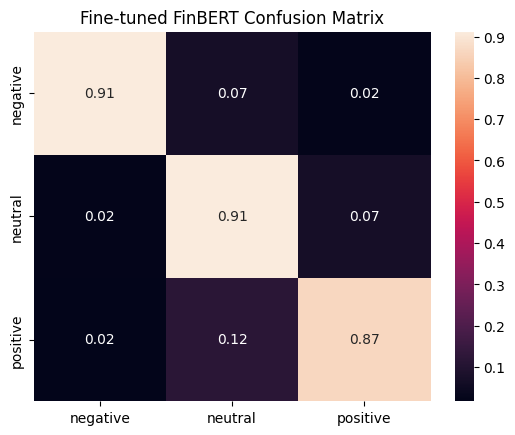

In [95]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("../models/finetuned_finbert_tweaked1", weights_only=True))

test_dataset = CustomDataset(
    text=test_df['sentence'].tolist(),
    labels=y_test,
    tokenizer=tokenizer
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

test_loss, test_preds, test_labels = eval_epoch(model.to(device), test_loader, device)
test_f1 = f1_score(test_labels, test_preds, average="weighted")
print(f"Test Loss: {test_loss:.4f} | Test F1: {test_f1:.4f}")
print(classification_report(test_labels, test_preds, target_names=le.classes_))

cm = confusion_matrix(test_labels, test_preds, normalize='true')
fig = sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=le.classes_, yticklabels=le.classes_)
fig.set_title('Fine-tuned FinBERT Confusion Matrix')
fig = fig.get_figure()
fig.savefig("../src/visualization/confusion_matrix_finbert.png", bbox_inches='tight')

In [96]:
import joblib
from sklearn.metrics import f1_score, accuracy_score


tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
logreg_best = joblib.load('../models/logreg_best.pkl')
xgb_best = joblib.load('../models/xgb_best.pkl')

X_test_tfidf = tfidf.transform(test_df['clean_text'])
y_test_str = test_df['sentiment']

logreg_pred = logreg_best.predict(X_test_tfidf)
xgb_pred = le.inverse_transform(xgb_best.predict(X_test_tfidf))

finbert_pred = le.inverse_transform(test_preds)
finbert_labels = le.inverse_transform(test_labels)

## 4. Model Comparison

In [97]:
results = [
    {
        'Model': 'LogReg (GridSearchCV)',
        'Macro F1': f1_score(y_test_str, logreg_pred, average='macro'),
        'Weighted F1': f1_score(y_test_str, logreg_pred, average='weighted'),
        'Accuracy': accuracy_score(y_test_str, logreg_pred),
    },
    {
        'Model': 'XGBoost (Optuna)',
        'Macro F1': f1_score(y_test_str, xgb_pred, average='macro'),
        'Weighted F1': f1_score(y_test_str, xgb_pred, average='weighted'),
        'Accuracy': accuracy_score(y_test_str, xgb_pred),
    },
    {
        'Model': 'FinBERT (zero-shot)',
        'Macro F1': f1_score(y_test_str, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test_str, y_pred, average='weighted'),
        'Accuracy': accuracy_score(y_test_str, y_pred),
    },
    {
        'Model': 'FinBERT (fine-tuned)',
        'Macro F1': f1_score(finbert_labels, finbert_pred, average='macro'),
        'Weighted F1': f1_score(finbert_labels, finbert_pred, average='weighted'),
        'Accuracy': accuracy_score(finbert_labels, finbert_pred),
    },
]

df_results = pd.DataFrame(results).set_index('Model')
print(df_results)

                       Macro F1  Weighted F1  Accuracy
Model                                                 
LogReg (GridSearchCV)  0.642266     0.701481  0.701102
XGBoost (Optuna)       0.619266     0.692391  0.707300
FinBERT (zero-shot)    0.884723     0.893795  0.892562
FinBERT (fine-tuned)   0.888898     0.899001  0.898760
